In [147]:
import xarray as xr
import matplotlib.pyplot as plt

In [148]:
time = "2024-07-01T12:00:00"

In [149]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=time)

In [150]:
data_era.height.values

array([2.00000000e+00, 1.38184021e+02, 3.52778076e+02, 5.71302612e+02,
       7.93885925e+02, 1.02091638e+03, 1.25297986e+03, 1.49036707e+03,
       1.73332227e+03, 1.98217236e+03, 2.23730591e+03, 2.49934717e+03,
       3.04730103e+03, 3.63040845e+03, 4.25232910e+03, 4.91959961e+03,
       5.64320801e+03, 6.42826514e+03, 7.28562158e+03, 8.23246191e+03,
       9.29184277e+03, 1.05011475e+04, 1.11942344e+04, 1.19792471e+04])

In [151]:
cabauw_data = xr.open_mfdataset(r'..\data\model_inputs\Cabauw_radiometer\radiometer_profile_data.nc')
cabauw_data = cabauw_data.sel(time=time,method='nearest')
cabauw_data = cabauw_data.sel(height=slice(200,10000))

In [152]:
levels_in_range = data_era.level.where((data_era.height >= 200) & (data_era.height <= 10000), drop=True)

# Get integer indices of these levels:
heights_plot = data_era.height.sel(level=levels_in_range)
humidity_plot = data_era.specific_humidity.sel(level=levels_in_range)

In [153]:
levels_in_range

<xarray.DataArray 'level' (level: 19)> Size: 152B
array([97500., 95000., 92500., 90000., 87500., 85000., 82500., 80000.,
       77500., 75000., 70000., 65000., 60000., 55000., 50000., 45000.,
       40000., 35000., 30000.])
Coordinates:
    latitude    float64 8B 52.0
    longitude   float64 8B 5.0
    valid_time  datetime64[ns] 8B 2024-07-01T12:00:00
    number      int64 8B 0
    expver      <U4 16B '0001'
  * level       (level) float64 152B 9.75e+04 9.5e+04 9.25e+04 ... 3.5e+04 3e+04

[]

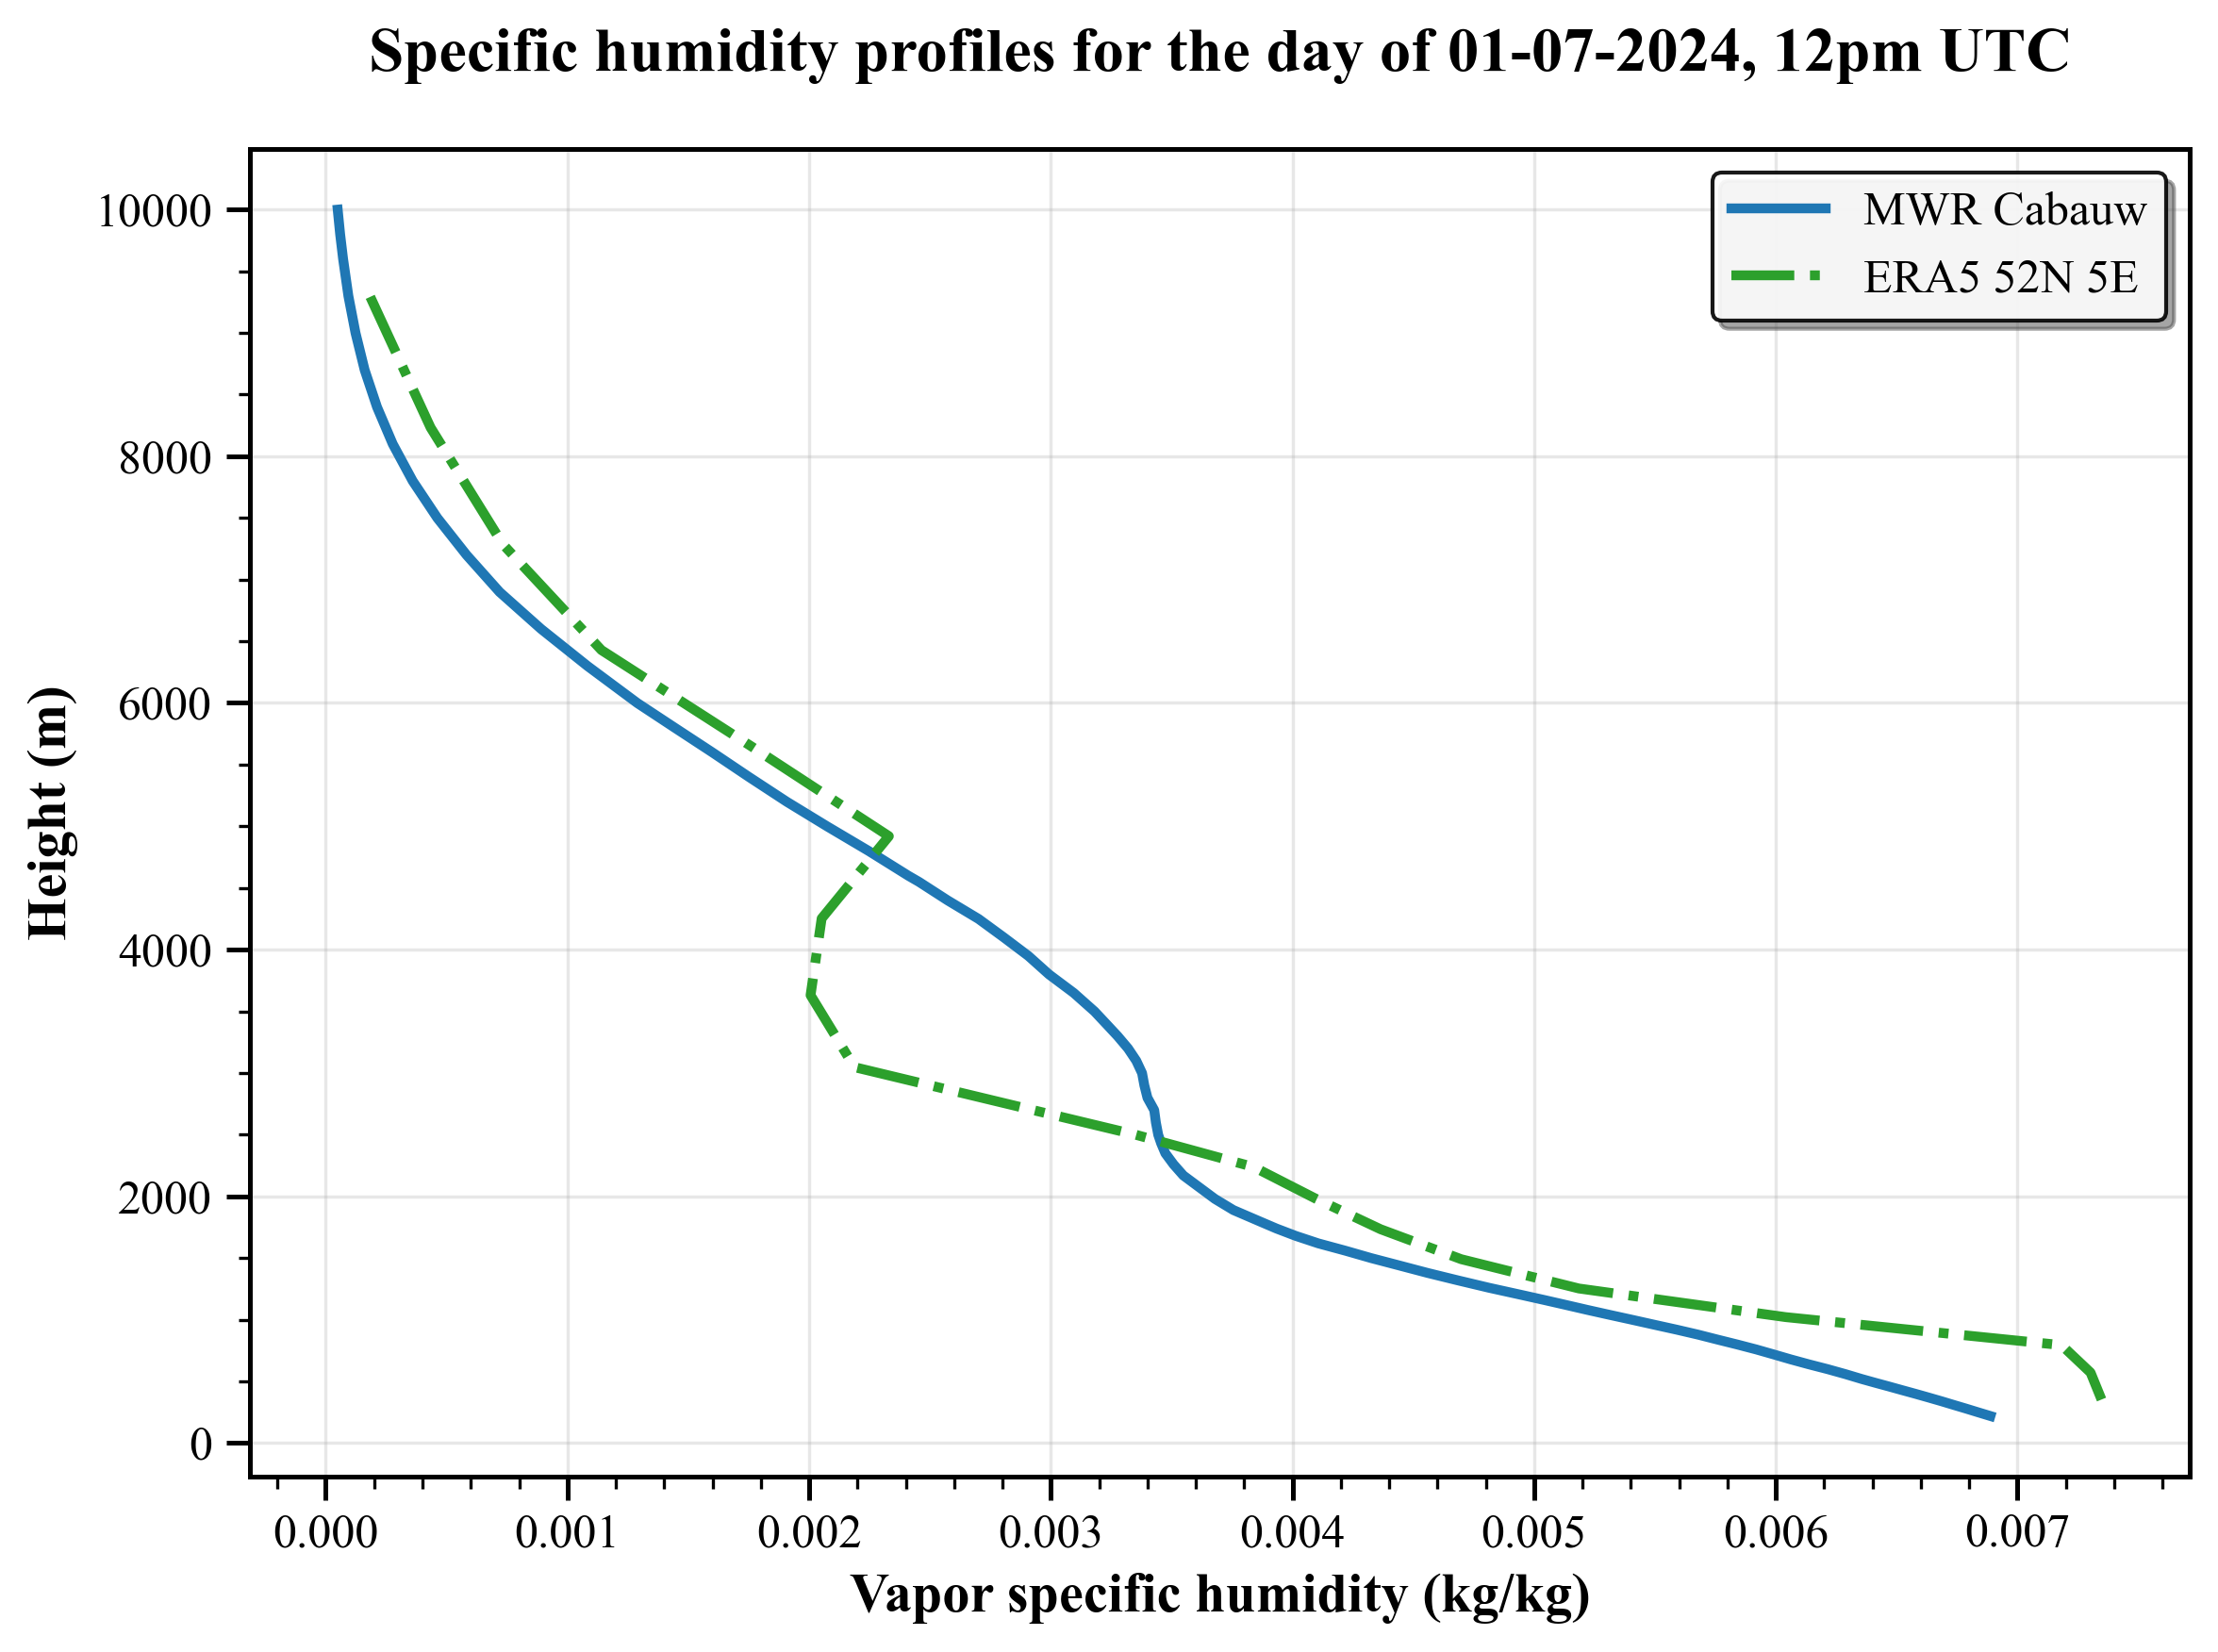

In [159]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

fig, ax = plt.subplots(figsize=(8, 6))

# Your plot with improved styling
ax.plot(cabauw_data.specific_humidity, cabauw_data.height, 
        linewidth=2.5, 
        color='#1f77b4',  # Professional blue
        label='MWR Cabauw')
ax.plot(humidity_plot, heights_plot, 
        linewidth=2.5, 
        color='#2ca02c',  # Professional green
        linestyle='-.',
        label='ERA5 52N 5E')

# Improved formatting
ax.set_xlabel('Vapor specific humidity (kg/kg)', fontweight='bold')
ax.set_ylabel('Height (m)', fontweight='bold')
ax.set_title('Specific humidity profiles for the day of 01-07-2024, 12pm UTC', 
             fontweight='bold', pad=20)

# Better axis limits and ticks
#ax.set_ylim(400, 200)  # Note: inverted, so high to low
#ax.set_xlim(240, 280)  # Adjust based on your data range

# Professional grid
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)  # Grid behind data

# Improved legend
legend = ax.legend(loc='upper right', 
                   frameon=True, 
                   fancybox=True, 
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)
# Tight layout
plt.tight_layout()

plt.plot()
plt.plot()